In [ ]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
# TrashNET https://github.com/garythung/trashnet/blob/master/data/dataset-resized.zip

In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU kullanılabilir:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU kullanılabilir: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


In [5]:
import os
from pathlib import Path

def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(
      f"# of directories: {len(dirnames)} and "
      f"{len(filenames)} images in '{dirpath}'."
    )

image_path = Path("dataset-resized")

check_data(image_path)


# of directories: 6 and 1 images in 'dataset-resized'.
# of directories: 0 and 403 images in 'dataset-resized\cardboard'.
# of directories: 0 and 501 images in 'dataset-resized\glass'.
# of directories: 0 and 410 images in 'dataset-resized\metal'.
# of directories: 0 and 594 images in 'dataset-resized\paper'.
# of directories: 0 and 482 images in 'dataset-resized\plastic'.
# of directories: 0 and 137 images in 'dataset-resized\trash'.


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [7]:
from torchvision import datasets
from torch.utils.data import Subset

train_dataset = datasets.ImageFolder(
    root=image_path,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=image_path,
    transform=test_transform
)

In [8]:
generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    len(train_dataset),
    generator=generator
).tolist()

train_size = int(0.8 * len(indices))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

train_data = Subset(train_dataset, train_indices)
test_data = Subset(test_dataset, test_indices)


In [9]:
print(f"total: {len(indices)}")
print(f"train: {len(train_data)}")
print(f"test: {len(test_data)}")
print(f"classes: {train_dataset.classes}")

total: 2527
train: 2021
test: 506
classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [10]:
class_names = train_dataset.classes

In [11]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=False)

Text(0.5, 1.0, 'trash')

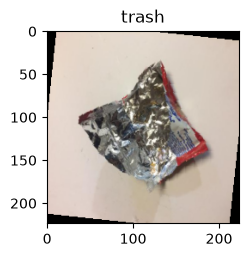

In [12]:
image, label = train_data[0]

image_for_plot = image * 0.5 + 0.5
image_for_plot = image_for_plot.permute(1, 2, 0)

plt.figure(figsize=(2.5, 2.5))
plt.imshow(image_for_plot)
plt.title(class_names[label])

In [13]:
class TrashNETClassifier(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.block_1 = nn.Sequential(
      nn.Conv2d(in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1),
      nn.BatchNorm2d(hidden_units),
      nn.ReLU(),

      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1),
      nn.BatchNorm2d(hidden_units),
      nn.ReLU(),

      nn.MaxPool2d(kernel_size=2)
    )

    self.block_2 = nn.Sequential(
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1),
      nn.BatchNorm2d(hidden_units),
      nn.ReLU(),

      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1),
      nn.BatchNorm2d(hidden_units),
      nn.ReLU(),

      nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_units*56*56,
                out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    return self.classifier(self.block_2(self.block_1(x)))

In [14]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model = TrashNETClassifier(
    input_shape=3,
    hidden_units=32,
    output_shape=len(class_names)
).to(device)

In [15]:
from torchinfo import summary
summary(model, input_size=[1, 3, 224, 224])

Layer (type:depth-idx)                   Output Shape              Param #
TrashNETClassifier                       [1, 6]                    --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         --
│    └─Conv2d: 2-4                       [1, 32, 224, 224]         9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 224, 224]         64
│    └─ReLU: 2-6                         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-7                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 32, 56, 56]           --
│    └─Conv2d: 2-8                       [1, 32, 112, 112]         9,248
│    └─BatchNorm2d: 2-9                  [1, 32, 112, 112]         64
│    └─ReLU: 2-10                        [1, 32, 112, 112]         --
│    └─C

In [16]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):

  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):

    X = X.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)

    y_pred = model(X)
    loss = loss_fn(y_pred, y)

    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    y_pred_class = torch.softmax(y_pred, dim=1).argmax(dim=1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [17]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

  model.eval()

  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):

      X = X.to(device, non_blocking=True)
      y = y.to(device, non_blocking=True)
      
      test_pred_logits = model(X)
      loss = loss_fn(test_pred_logits, y)

      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

In [18]:
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

  results = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
  }

  for epoch in range(epochs):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)
    print(
      f"Epoch: {epoch+1} | "
      f"train_loss: {train_loss:.4f} | "
      f"train_acc: {train_acc:.4f} | "
      f"test_loss: {test_loss:.4f} | "
      f"test_acc: {test_acc:.4f}"
    )

    results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
    results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

  return results

In [19]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 15

model = TrashNETClassifier(
    input_shape=3,
    hidden_units=32,
    output_shape=len(class_names)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

model_results = train(model=model, 
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

Epoch: 1 | train_loss: 10.0376 | train_acc: 0.3400 | test_loss: 2.9561 | test_acc: 0.4117
Epoch: 2 | train_loss: 3.6873 | train_acc: 0.4308 | test_loss: 3.7154 | test_acc: 0.5029
Epoch: 3 | train_loss: 3.2098 | train_acc: 0.4674 | test_loss: 2.8498 | test_acc: 0.5227
Epoch: 4 | train_loss: 1.7421 | train_acc: 0.5429 | test_loss: 1.4117 | test_acc: 0.5883
Epoch: 5 | train_loss: 1.5431 | train_acc: 0.5624 | test_loss: 1.3238 | test_acc: 0.5741
Epoch: 6 | train_loss: 1.2195 | train_acc: 0.6048 | test_loss: 1.3642 | test_acc: 0.5795
Epoch: 7 | train_loss: 1.1375 | train_acc: 0.6215 | test_loss: 1.3742 | test_acc: 0.5517
Epoch: 8 | train_loss: 1.0744 | train_acc: 0.6383 | test_loss: 1.5981 | test_acc: 0.5033
Epoch: 9 | train_loss: 1.5635 | train_acc: 0.5828 | test_loss: 1.1709 | test_acc: 0.6342
Epoch: 10 | train_loss: 1.0137 | train_acc: 0.6517 | test_loss: 1.1734 | test_acc: 0.5877
Epoch: 11 | train_loss: 0.8685 | train_acc: 0.6878 | test_loss: 1.0108 | test_acc: 0.6615
Epoch: 12 | train_

In [20]:
model_results

{'train_loss': [10.037621546536684,
  3.6873462330549955,
  3.2098216637969017,
  1.7421156037598848,
  1.5430608876049519,
  1.2194803711026907,
  1.1375101255252957,
  1.0743569415062666,
  1.563467805273831,
  1.0136655494570732,
  0.868502339348197,
  1.0064104730263352,
  0.8259045332670212,
  0.8392968364059925,
  0.8340522730723023],
 'train_acc': [0.3400390625,
  0.43076171875,
  0.4673828125,
  0.54287109375,
  0.56240234375,
  0.60478515625,
  0.621484375,
  0.63828125,
  0.5828125,
  0.65166015625,
  0.68779296875,
  0.6505859375,
  0.70029296875,
  0.70810546875,
  0.72080078125],
 'test_loss': [2.956127777695656,
  3.7154276072978973,
  2.849750265479088,
  1.4116980955004692,
  1.323765467852354,
  1.3641783446073532,
  1.3742237649857998,
  1.5981126055121422,
  1.170887965708971,
  1.1734099872410297,
  1.0108250863850117,
  0.9444204792380333,
  0.8415801785886288,
  0.8744384311139584,
  0.9208983443677425],
 'test_acc': [0.41165865384615385,
  0.5028545673076923,
  0

In [21]:
import matplotlib.pyplot as plt

def plot_loss_curves(results):
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

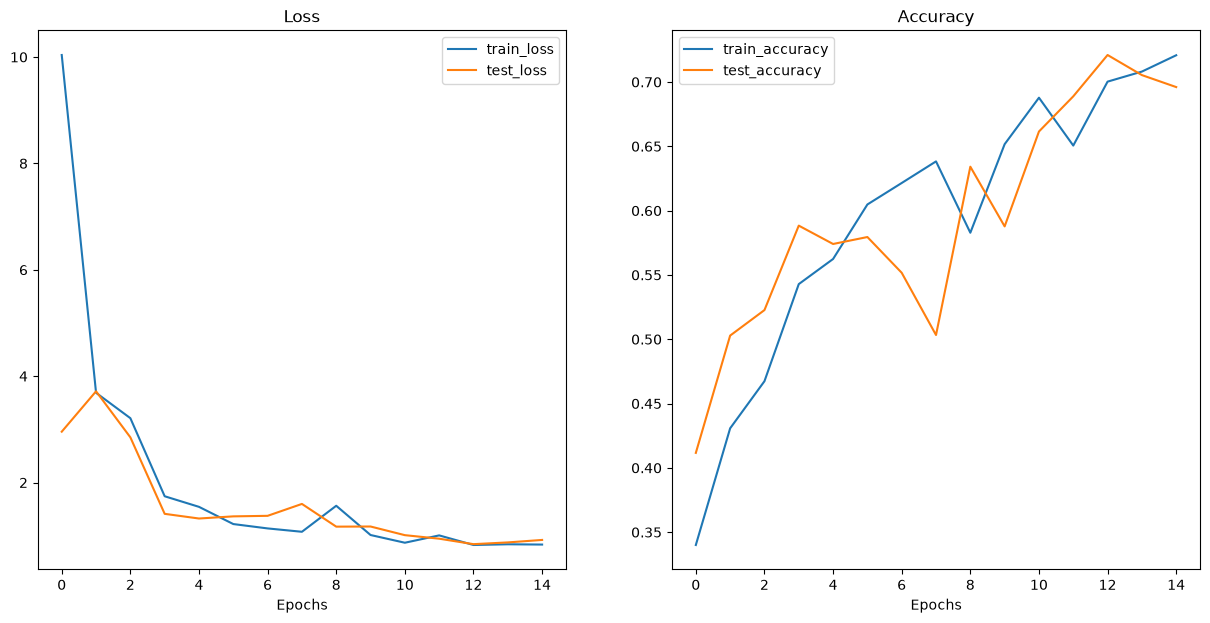

In [22]:
plot_loss_curves(model_results)

In [23]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Hepsini birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [47]:
import random

def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()
    model_device = next(model.parameters()).device

    plt.figure(figsize=(7.5, 7.5))
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # Görüntüyü modelin bulunduğu cihaza gönder
            img_input = img.unsqueeze(0).to(model_device)

            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # Normalizasyonu geri al ve görselleştir
            img_show = img * 0.5 + 0.5
            img_show = img_show.permute(1, 2, 0).clamp(0, 1)

            correct = pred_label == true_label
            color = "green" if correct else "red"

            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")
            plt.title(
                f"Pred: {class_names[pred_label]}\n"
                f"True: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

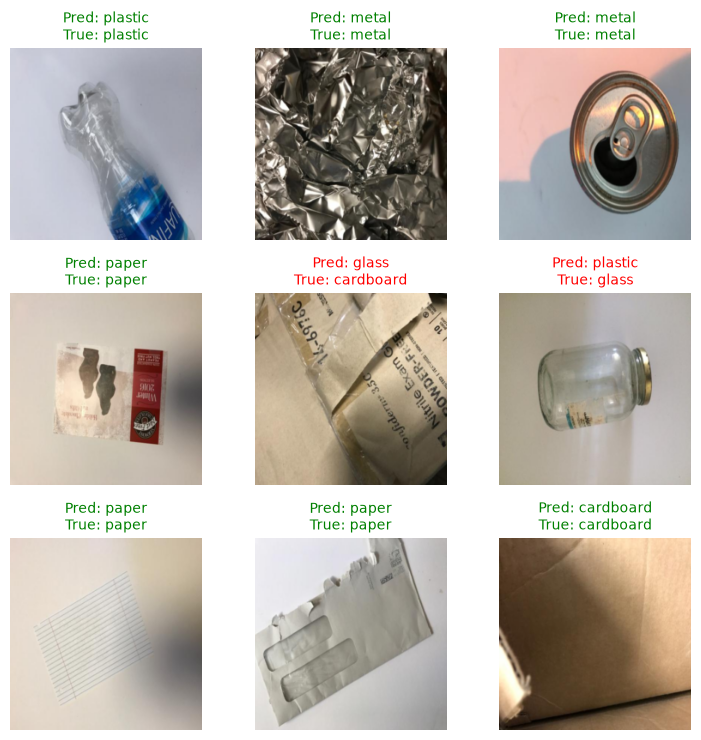

In [119]:
show_random_predictions(
    model=model,
    dataset=test_data,
    class_names=class_names,
    n=9
)